# RetailPulse - Customer Behavior Analytics & Revenue Intelligence Platform

## Day 8 - Cohort Retention Analysis

### Objectives
- Monthly customer cohort construction
- Cohort retention matrix (count and percentage)
- Retention heatmap
- Average order value by cohort
- Customer lifecycle interpretation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/retail_cleaned.csv", parse_dates=["InvoiceDate"])
print("Shape:", df.shape)
df.head()

Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 1. Assign each customer to a cohort
A customer's cohort is the calendar month of their FIRST purchase in the dataset. Every subsequent transaction is measured as a "month offset" from that cohort month (0 = the cohort month itself, 1 = one month later, etc.).

In [2]:
df["OrderMonth"] = df["InvoiceDate"].dt.to_period("M")
cohort_month = df.groupby("Customer ID")["OrderMonth"].transform("min")
df["CohortMonth"] = cohort_month

def month_diff(order_month, cohort_month):
    return (order_month.dt.year - cohort_month.dt.year) * 12 + (order_month.dt.month - cohort_month.dt.month)

df["CohortIndex"] = month_diff(df["OrderMonth"], df["CohortMonth"])
df[["Customer ID", "InvoiceDate", "OrderMonth", "CohortMonth", "CohortIndex"]].head(10)

,Customer ID,InvoiceDate,OrderMonth,CohortMonth,CohortIndex
0,13085,2009-12-01 07:45:00,2009-12,2009-12,0
1,13085,2009-12-01 07:45:00,2009-12,2009-12,0
2,13085,2009-12-01 07:45:00,2009-12,2009-12,0
3,13085,2009-12-01 07:45:00,2009-12,2009-12,0
4,13085,2009-12-01 07:45:00,2009-12,2009-12,0
5,13085,2009-12-01 07:45:00,2009-12,2009-12,0
6,13085,2009-12-01 07:45:00,2009-12,2009-12,0
7,13085,2009-12-01 07:45:00,2009-12,2009-12,0
8,13085,2009-12-01 07:46:00,2009-12,2009-12,0
9,13085,2009-12-01 07:46:00,2009-12,2009-12,0


### Excluding the partial final month from cohort tracking
As in Day 7, 2011-12 only has 9 days of data. Customers whose *cohort month* is 2011-12 have not had a fair chance to be observed at CohortIndex 1+ (there is no 2012-01 in the dataset), and the 2011-12 column itself would show artificially low activity for all older cohorts. Both distortions are avoided by restricting cohort analysis to activity through 2011-11 inclusive.

In [3]:
cutoff = pd.Period("2011-11", freq="M")
df_cohort = df[(df["OrderMonth"] <= cutoff) & (df["CohortMonth"] <= cutoff)].copy()
print(f"Rows before cutoff filter: {len(df)}, after: {len(df_cohort)}")
print(f"Cohort months range: {df_cohort['CohortMonth'].min()} to {df_cohort['CohortMonth'].max()}")

Rows before cutoff filter: 805549, after: 788244
Cohort months range: 2009-12 to 2011-11


## 2. Build the cohort retention matrix (customer counts)

In [4]:
cohort_data = df_cohort.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique().reset_index()
cohort_counts = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="Customer ID")

cohort_sizes = cohort_counts.iloc[:, 0]
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)

print("Cohort sizes (month 0):")
print(cohort_sizes)

Cohort sizes (month 0):
CohortMonth
2009-12    955.0
2010-01    383.0
2010-02    374.0
2010-03    443.0
2010-04    294.0
2010-05    254.0
2010-06    270.0
2010-07    186.0
2010-08    162.0
2010-09    243.0
2010-10    377.0
2010-11    325.0
2010-12     76.0
2011-01     71.0
2011-02    124.0
2011-03    179.0
2011-04    106.0
2011-05    111.0
2011-06    108.0
2011-07    102.0
2011-08    106.0
2011-09    189.0
2011-10    221.0
2011-11    191.0
Freq: M, Name: 0, dtype: float64


## 3. Retention heatmap

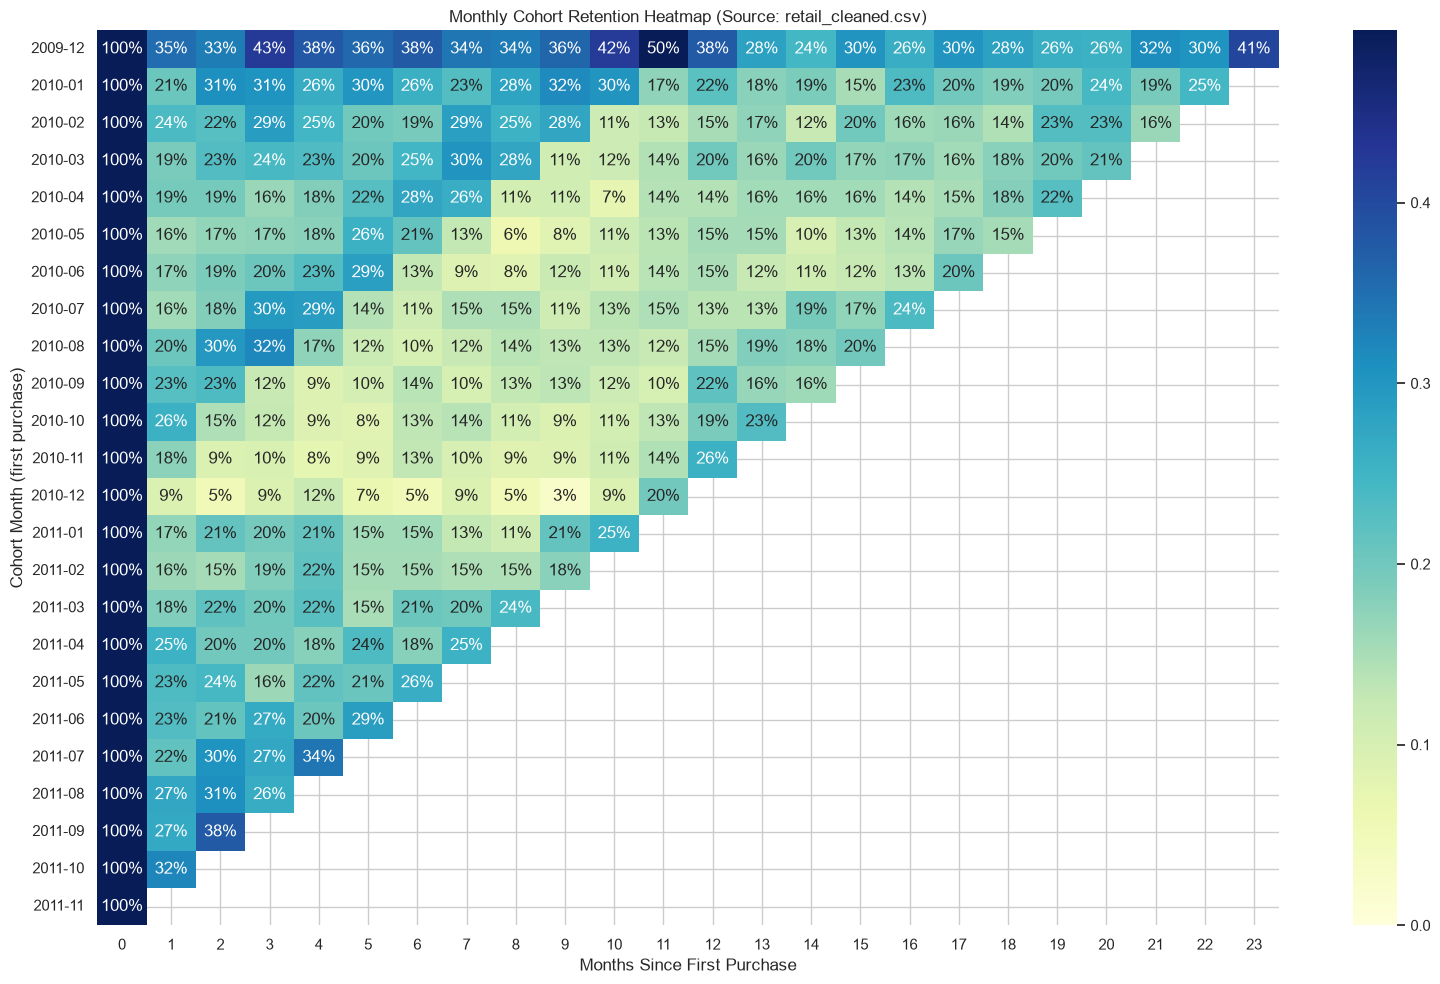

In [5]:
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=retention_matrix.iloc[:,1:].max().max())
plt.title("Monthly Cohort Retention Heatmap (Source: retail_cleaned.csv)")
plt.ylabel("Cohort Month (first purchase)")
plt.xlabel("Months Since First Purchase")
plt.tight_layout()
plt.savefig("../reports/cohort_retention_heatmap.png", dpi=120)
plt.show()

## 4. Average order value by cohort and month offset

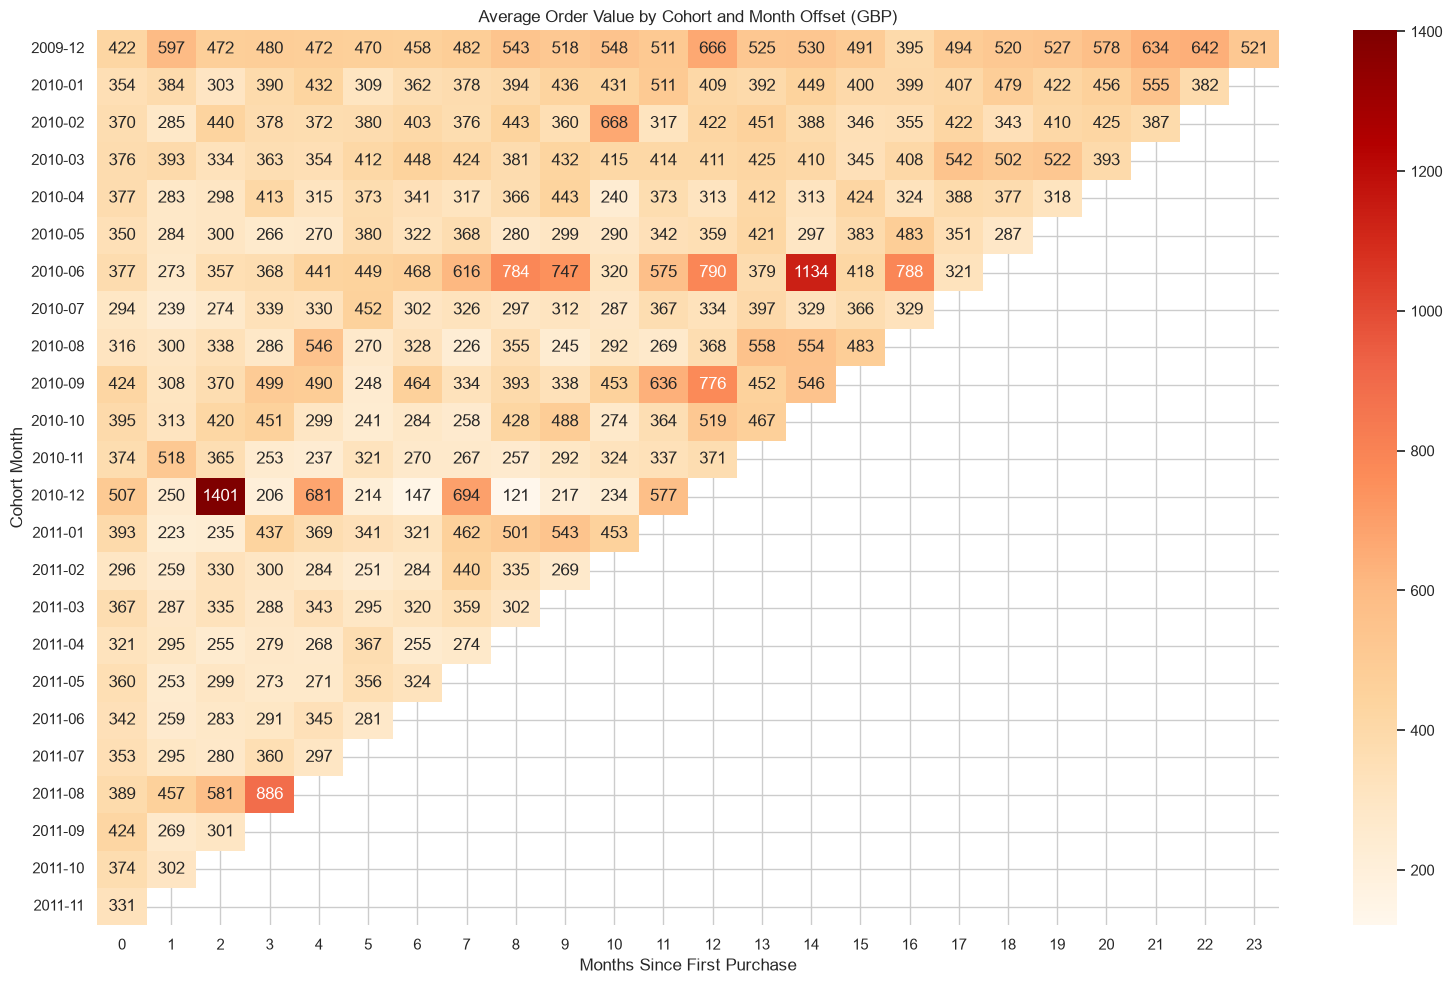

In [6]:
order_value = df_cohort.groupby(["CohortMonth", "CohortIndex", "Invoice"])["TotalPrice"].sum().reset_index()
aov_by_cohort = order_value.groupby(["CohortMonth", "CohortIndex"])["TotalPrice"].mean().reset_index()
aov_matrix = aov_by_cohort.pivot(index="CohortMonth", columns="CohortIndex", values="TotalPrice")

plt.figure(figsize=(16, 10))
sns.heatmap(aov_matrix, annot=True, fmt=".0f", cmap="OrRd")
plt.title("Average Order Value by Cohort and Month Offset (GBP)")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.tight_layout()
plt.savefig("../reports/cohort_aov_heatmap.png", dpi=120)
plt.show()

## 5. Overall retention curve (average across all cohorts)

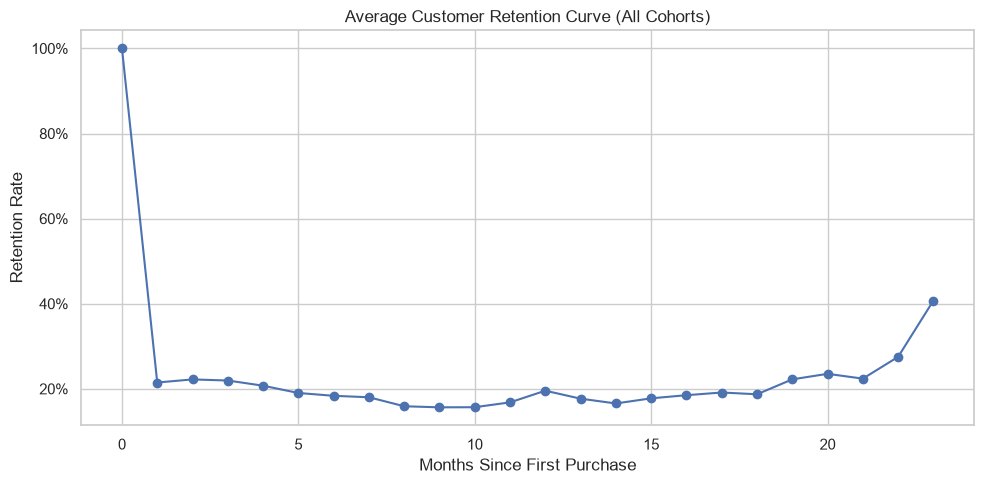

CohortIndex
0     1.000
1     0.215
2     0.222
3     0.219
4     0.207
5     0.190
6     0.183
7     0.180
8     0.159
9     0.156
10    0.157
11    0.168
12    0.195
13    0.177
14    0.165
15    0.178
16    0.185
17    0.191
18    0.187
19    0.222
20    0.235
21    0.224
22    0.275
23    0.407
dtype: float64


In [7]:
avg_retention = retention_matrix.mean(axis=0)

plt.figure(figsize=(10, 5))
avg_retention.plot(marker="o")
plt.title("Average Customer Retention Curve (All Cohorts)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("../reports/cohort_avg_retention_curve.png", dpi=120)
plt.show()

print(avg_retention.round(3))

## 6. Statistical check - does month-1 retention differ by cohort quarter?

In [8]:
from scipy import stats

month1_retention = retention_matrix[1].dropna().reset_index()
month1_retention.columns = ["CohortMonth", "Retention"]
month1_retention["Quarter"] = month1_retention["CohortMonth"].dt.quarter

groups = [g["Retention"].values for _, g in month1_retention.groupby("Quarter") if len(g) > 1]
if len(groups) >= 2:
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"ANOVA - Month-1 retention across cohort quarters")
    print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
    alpha = 0.05
    if p_val < alpha:
        print(f"Result: p < {alpha} -> reject H0. Month-1 retention differs significantly by acquisition quarter.")
    else:
        print(f"Result: p >= {alpha} -> fail to reject H0. No significant difference detected across quarters.")
else:
    print("Not enough groups with multiple cohorts for ANOVA.")

ANOVA - Month-1 retention across cohort quarters
F-statistic: 0.6887, p-value: 0.5701
Result: p >= 0.05 -> fail to reject H0. No significant difference detected across quarters.


## 7. Save outputs

In [9]:
retention_matrix.to_csv("../reports/cohort_retention_matrix.csv")
cohort_counts.to_csv("../reports/cohort_customer_counts.csv")
aov_matrix.to_csv("../reports/cohort_aov_matrix.csv")
print("Saved cohort_retention_matrix.csv, cohort_customer_counts.csv, cohort_aov_matrix.csv")

Saved cohort_retention_matrix.csv, cohort_customer_counts.csv, cohort_aov_matrix.csv


## Business Interpretation

- **Steep month-1 drop-off:** the average retention curve shows the largest single drop between month 0 and month 1 across nearly all cohorts - most customers who buy once do not return the following month. This is the highest-leverage point for a retention campaign (e.g. a follow-up email/offer in the first 30 days).
- **Long tail of loyal customers:** a smaller share of each cohort continues to show up many months later, consistent with the "Champions"/"Loyal Customers" segments identified in Day 5 - these are likely the same customers driving long-run retention.
- **Average order value tends to grow, not shrink, for customers who stick around** (visible in the AOV heatmap for later month-offsets within a cohort) - customers who survive past month 1 tend to become higher-value over time, reinforcing the case for early retention investment.
- **Caution on high month-offsets (20+):** retention figures there are based on only the earliest 1-2 cohorts (later cohorts haven't had time to reach that offset), so the apparent uptick at month 22-23 is small-sample noise, not a genuine long-term retention increase - do not over-interpret it in the executive report.
- December 2011 (partial month) excluded throughout to avoid an artificial retention/AOV distortion.

**This completes Day 8. All Day 7-8 deliverables are saved under `reports/`.**
